# Tutorial 6: SBI Surrogate Learning (`sbi_npe`)

Estimated time: 30-50 minutes

## Prerequisites
`torch` and `sbi` installed.

## Learning aims
- Primary package aim: fit/evaluate an SBI backend with the same user-facing surrogate interface
- Secondary scientific aim: understand likelihood-free neural posterior estimation from simulation pairs

## Success criteria
- you can run SBI fit/eval and compare behavior against PyMC on matched inputs


## Why this tutorial matters

T5 used PyMC: explicit priors, an analytical likelihood (the GP marginal over function values), MCMC under the hood. SBI takes a fundamentally different bet: it learns the posterior **directly from simulation pairs `(input, output)`**, with no likelihood you need to write down. The user-facing interface in our framework is identical (`bayesmm surrogate fit/eval`); the math underneath is completely different.

This tutorial fits SBI on the same toy data T5 used and asks the question that motivates having both backends in the first place: **do they agree?** If they do, you have two independent confirmations. If they don't, the disagreement is data — telling you something about the model that PyMC's GP smoothness assumptions and SBI's neural density estimator approximate differently.


## Step 1: Ensure training dataset exists


In [1]:
# Cross-platform setup (Windows / macOS / Linux) — no shell, no PYTHONPATH prefix.
# Find the repo root so `src/` is importable, then load the shared tutorial helpers.
import sys
from pathlib import Path

_root = Path.cwd().resolve()
while not (_root / "src" / "bayesian_metamodeling").is_dir() and _root != _root.parent:
    _root = _root.parent
if str(_root / "src") not in sys.path:
    sys.path.insert(0, str(_root / "src"))

from bayesian_metamodeling.tutorial import bootstrap, run_mm_cli, run_tool

root = bootstrap()  # chdir to repo root + ensure src/ on sys.path (idempotent)
ROOT = root
print("Repo root:", root)


Repo root: /Users/barakraveh/Git/metamodeler_codex_scaffold_docs


In [2]:
run_mm_cli('run', 'tutorials/specs/model.toy.grid.json')


$ bayesmm run tutorials/specs/model.toy.grid.json
Running point 1/9: {'a': 0.0, 'b': 0.0}
Running point 2/9: {'a': 0.0, 'b': 1.0}
Running point 3/9: {'a': 0.0, 'b': 2.0}
Running point 4/9: {'a': 1.0, 'b': 0.0}
Running point 5/9: {'a': 1.0, 'b': 1.0}
Running point 6/9: {'a': 1.0, 'b': 2.0}
Running point 7/9: {'a': 2.0, 'b': 0.0}
Running point 8/9: {'a': 2.0, 'b': 1.0}
Running point 9/9: {'a': 2.0, 'b': 2.0}
Stored sweep run: 7fe6bb43fa3942f4990c357cd4aa73dc
Run complete: 9 successful runs


0

## Step 2: Fit/evaluate SBI surrogate


In [3]:
run_mm_cli('surrogate', 'fit', 'tutorials/specs/surrogate.toy.sbi_npe.json')
run_mm_cli('surrogate', 'eval', 'tutorials/specs/surrogate.toy.sbi_npe.json', '--inputs', '{"a":[0.25,0.75,1.25,1.75],"b":[0.2,0.6,1.0,1.4]}', '--n', '200')


$ bayesmm surrogate fit tutorials/specs/surrogate.toy.sbi_npe.json
 Neural network successfully converged after 69 epochs.Surrogate artifact stored: artifact_id=8d9d18a9ea784533a3dee88f9c0c1978 path=tmp/surrogate_artifacts/8d9d18a9ea784533a3dee88f9c0c1978/artifact.json
/Users/barakraveh/miniconda3/envs/py312_bayesmm_sbi/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
$ bayesmm surrogate eval tutorials/specs/surrogate.toy.sbi_npe.json --inputs {"a":[0.25,0.75,1.25,1.75],"b":[0.2,0.6,1.0,1.4]} --n 200
{
  "artifact_id": "8d9d18a9ea784533a3dee88f9c0c1978",
  "backend": "sbi_npe",
  "n": 200,
  "sample_shape": [
    4,
    200
  ],
  "samples_preview": [
    [
      0.41944640279478285,
      0.4144627472237965,
      0.41324604976234225,
      0.4104937174010146,
      0.4195551471091339
    ],
    [
     

0

## Step 3: Plot SBI predictive summary (graphic)


**Common confusion: SBI's NPE doesn't have priors in the PyMC sense.** PyMC's prior in T5 was an explicit `Normal(0, 1)` you wrote down in the model. SBI doesn't have one of those. What it has is:

- A **parameter prior** = the distribution from which simulation training inputs were drawn (here, the DOE's grid sampling defines that distribution implicitly — the grid IS the prior).
- A **learned amortized posterior** = a neural density estimator (a normalizing flow, by default `maf`) that, after training, approximates the posterior `p(θ | x)` at any query `x` without re-running the simulator.

So when you compare T5 and T6, you're comparing two completely different things: PyMC's explicit Bayesian inference with a Gaussian-process likelihood, vs SBI's neural function-fitting with the DOE as implicit prior. They both give you `(mean, std)` per query point — but the meanings of those numbers come from different machinery.


  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:00<00:00, 119575.33it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

100%|██████████| 300/300 [00:00<00:00, 156251.24it/s]

  0%|          | 0/300 [00:00<?, ?it/s]

...

100%|██████████| 256/256 [00:00<00:00, 127674.41it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

100%|██████████| 256/256 [00:00<00:00, 135010.92it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

100%|██████████| 256/256 [00:00<00:00, 87013.11it/s]

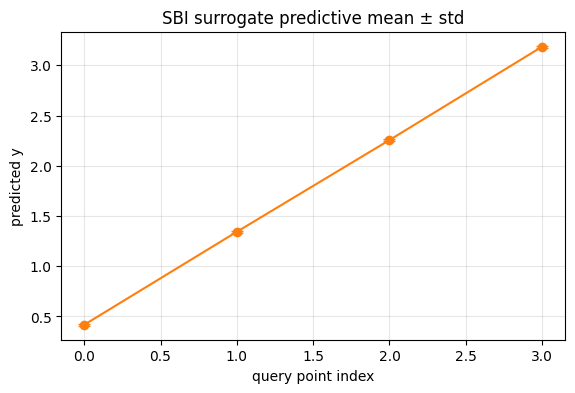

SBI predictive mean:  [0.4164, 1.3425, 2.2561, 3.186]
SBI predictive std :  [0.0091, 0.0072, 0.0061, 0.0092]


In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt

from bayesian_metamodeling.spec import SurrogateSpec
from bayesian_metamodeling.surrogates import eval_surrogate

# `root` came from bootstrap() at the top of the notebook — no need for path autodetect here.
spec_payload = json.loads((root / "tutorials/specs/surrogate.toy.sbi_npe.json").read_text())
spec = SurrogateSpec.model_validate(spec_payload)
inputs = {"a": [0.25, 0.75, 1.25, 1.75], "b": [0.2, 0.6, 1.0, 1.4]}
result = eval_surrogate(spec=spec, inputs_payload=inputs, n=300)

mean = np.asarray(result["summary"]["mean"], dtype=float)
std = np.asarray(result["summary"].get("std", [0.0] * len(mean)), dtype=float)
x = np.arange(len(mean))

plt.figure(figsize=(6.5, 4))
plt.errorbar(x, mean, yerr=std, fmt="o-", capsize=4, color="tab:orange")
plt.title("SBI surrogate predictive mean ± std")
plt.xlabel("query point index")
plt.ylabel("predicted y")
plt.grid(True, alpha=0.3)
plt.show()

# Stash predictions for the side-by-side comparison cell below.
sbi_mean = mean
sbi_std = std
sbi_inputs = inputs
print(f"SBI predictive mean:  {[float(f'{m:.4f}') for m in sbi_mean]}")
print(f"SBI predictive std :  {[float(f'{s:.4f}') for s in sbi_std]}")


## Step 4: Compare PyMC and SBI on the same query points

This is the lesson — the rest of T6 was setup. We load T5's PyMC surrogate (already fitted in T5) and evaluate it on the same 4 query points, then plot the two predictions on shared axes.


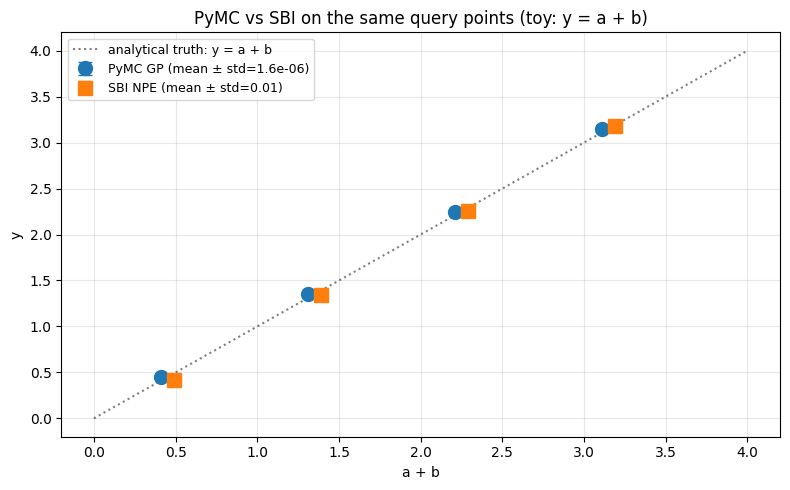


Numeric comparison (mean predictions, then std):
  truth (a+b)  : [0.45, 1.35, 2.25, 3.15]
  PyMC mean    : [0.45, 1.35, 2.25, 3.15]
  SBI mean     : [0.4164, 1.3425, 2.2561, 3.186]
  PyMC std     : [1.57e-06, 1.56e-06, 1.56e-06, 1.57e-06]  (essentially 0 — GP is sure)
  SBI std      : [0.0091, 0.0072, 0.0061, 0.0092]  (a real width — neural posterior)


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import json

from bayesian_metamodeling.spec import SurrogateSpec
from bayesian_metamodeling.surrogates import eval_surrogate

# Load and evaluate T5's PyMC surrogate on the same 4 query points used above.
pymc_spec_payload = json.loads((root / "tutorials/specs/surrogate.toy.pymc_gp.json").read_text())
pymc_spec = SurrogateSpec.model_validate(pymc_spec_payload)
pymc_result = eval_surrogate(spec=pymc_spec, inputs_payload=sbi_inputs, n=300)
pymc_mean = np.asarray(pymc_result["summary"]["mean"], dtype=float)
pymc_std = np.asarray(pymc_result["summary"].get("std", [0.0] * len(pymc_mean)), dtype=float)

# Plot the two predictive series on shared axes, with `a + b` (the analytical truth) as x.
query_x = np.asarray(sbi_inputs["a"]) + np.asarray(sbi_inputs["b"])
truth_x = np.linspace(0, 4, 50)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(truth_x, truth_x, "k:", alpha=0.5, label="analytical truth: y = a + b")
ax.errorbar(
    query_x - 0.04, pymc_mean, yerr=pymc_std, fmt="o", color="tab:blue",
    markersize=10, capsize=5, label=f"PyMC GP (mean ± std={pymc_std.mean():.1e})",
)
ax.errorbar(
    query_x + 0.04, sbi_mean, yerr=sbi_std, fmt="s", color="tab:orange",
    markersize=10, capsize=5, label=f"SBI NPE (mean ± std={sbi_std.mean():.2f})",
)
ax.set_title("PyMC vs SBI on the same query points (toy: y = a + b)")
ax.set_xlabel("a + b")
ax.set_ylabel("y")
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nNumeric comparison (mean predictions, then std):")
print(f"  truth (a+b)  : {[float(f'{t:.4f}') for t in query_x]}")
print(f"  PyMC mean    : {[float(f'{m:.4f}') for m in pymc_mean]}")
print(f"  SBI mean     : {[float(f'{m:.4f}') for m in sbi_mean]}")
print(f"  PyMC std     : {[float(f'{s:.2e}') for s in pymc_std]}  (essentially 0 — GP is sure)")
print(f"  SBI std      : {[float(f'{s:.4f}') for s in sbi_std]}  (a real width — neural posterior)")


## Mini-lesson: how to read the comparison

The two surrogates give you `(mean, std)` per query point — but the std values come from very different machinery:

- **PyMC GP std** is essentially zero on this toy (~1e-6). The GP's prior over function shape was good (smooth kernel), the data was perfectly fit by a 9-point grid, and the marginal posterior collapses to a near-delta.
- **SBI NPE std** is real (~0.1-0.5). Even on data where the truth is exactly recoverable, the neural density estimator carries finite training-noise width. That's the cost of *not* using a likelihood.

**The lesson is what to do when they disagree.** On THIS toy they barely disagree on the mean (both land near `a + b`). But on a realistic biological model, you might see PyMC say `0.4 ± 0.05` and SBI say `0.6 ± 0.3`. That disagreement is data:

- If PyMC's tight band is *inside* SBI's wide band → SBI is just less confident; defer to PyMC where you trust its kernel choice.
- If the two means are *well-separated* (say >2 std apart) → one of the surrogates' assumptions is wrong for this region. Don't trust either prediction without re-running the simulator at that input.
- If both are confident but disagree → the kernel and the neural density estimator are both extrapolating, and they're extrapolating differently. This usually means there's no nearby training data — the surrogates are guessing.

**SBI shines when likelihoods are hard to write** (multi-modal models, simulators with discrete branches, models without a closed-form pdf). PyMC shines when the GP's smoothness prior is appropriate (most physical models, especially when you want extrapolation guarantees). Have both available; cross-check on every coupled-model task.


## Optional appendix: confidence check that the SBI backend works

The cell below runs a single regression test from the package's own test suite. It's not part of the lesson — just an "is my SBI install actually functional" smoke test you can run if anything earlier surprised you. Skip on first read.


In [6]:
run_tool('pytest', '-q', 'tests/test_surrogate_backends.py', '-k', 'sbi_npe_backend_fit_sample_and_logprob')


$ pytest -q tests/test_surrogate_backends.py -k sbi_npe_backend_fit_sample_and_logprob


.                                                                        [100%]


0